In [1]:
# Explanation: The below imports all necessary libraries for data analysis and visualization. 
# we are using pandas for data manipulation, num for numerical operation, matplotlib and seaborn
# for graph and plotting, and datetime for handling data operation

In [81]:
# Importing Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# setting up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All Libraries imported successfully!")

All Libraries imported successfully!


In [82]:
# load data set
df = pd.read_csv("retail_sales.csv")
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


In [83]:
# Explanation : This cell provides basic information abount the dataset including dimension,column,names
# data types,and checks for missing value

In [84]:
# Basic data information structure
print("===DATASET BASIC INFORMATION===")
print(f"Dataset Dimension: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nColumn Names and Data Types:")
print(df.dtypes)

===DATASET BASIC INFORMATION===
Dataset Dimension: 1825 rows x 6 columns

Column Names and Data Types:
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object


In [85]:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Summary:")
df.info()


Missing Values:
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [88]:
# fill missing age with median. we use statistic function mean, median, mode: for numerical column we use mean and median and for categorical value we use mode.
df["Sales"] = df["Sales"].fillna(df["Sales"].mean()) # for numerical we use mean()
df["Quantity"] = df["Quantity"].fillna(df["Sales"].mean()) # for numerical we use mean()

df["Category"] = df["Category"].fillna(df["Category"].mode()[0]) # for catgorical column we use mode()
df["Region"] = df["Region"].fillna(df["Region"].mode()[0]) # for catgorical column we use mode()
print(df.isnull().sum())
df.info()

Date        0
Category    0
Sales       0
Quantity    0
Profit      0
Region      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1825 non-null   object 
 2   Sales     1825 non-null   float64
 3   Quantity  1825 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1825 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [87]:
# Explanation: This cell performs data cleaning by converting dates 
# extracting useful time-based features. It also ensures numeric columns

In [89]:
# Data type conversion and cleaning
print("===DATA CLEANING AND TYPE CONVERSION===")

# Convert date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Extract additional time feature
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["DayOfWeek"] = df["Date"].dt.day_name()
df["MonthName"] = df["Date"].dt.month_name()

# Ensure numeric columns are properly formated
numeric_columns = ["Sales","Quantity","Profit"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col],errors="coerce")
    
print("Data types after conversion:")
print(df.dtypes)
print(f"\nDate range: {df["Date"].min()} to {df["Date"].max()}")

===DATA CLEANING AND TYPE CONVERSION===
Data types after conversion:
Date         datetime64[ns]
Category             object
Sales               float64
Quantity            float64
Profit              float64
Region               object
Month                 int32
Quarter               int32
DayOfWeek            object
MonthName            object
dtype: object

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [69]:
# Explanation: This cell provides comprehensive statistical summary dispersion, and aggregation by category and region

In [90]:
# Basic statistical summary
print("===STATISTICAL SUMMARY===")
print("descriptive statistics for numerical Columns:")
print(df[["Sales","Quantity","Profit"]].describe())

===STATISTICAL SUMMARY===
descriptive statistics for numerical Columns:
             Sales     Quantity       Profit
count  1825.000000  1825.000000  1825.000000
mean    980.482677    12.712555   248.696130
std     336.571942    51.036906   118.159627
min       0.000000     0.000000     0.000000
25%     784.267165     5.000000   156.916498
50%     996.596443    10.000000   229.344557
75%    1208.163533    15.000000   324.867847
max    1888.932537   980.482677   703.228418


In [91]:
print("\nCategory-wise Summary:")
category_summary = df.groupby("Category").agg({
    "Sales":["count","sum","mean","std"],
    "Profit":["sum","mean"],
    "Quantity":["sum","mean"]
}).round(2)
print(category_summary)


Category-wise Summary:
            Sales                                Profit         Quantity  \
            count        sum     mean     std       sum    mean      sum   
Category                                                                   
Books         364  370971.87  1019.15  336.39  92304.45  253.58  3737.00   
Clothing      369  355420.13   963.20  336.42  90889.44  246.31  3670.00   
Electronics   361  365070.89  1011.28  343.78  90439.70  250.53  3595.00   
Home Goods    364  347493.83   954.65  332.39  87447.82  240.24  3777.00   
NaN?            1     828.59   828.59     NaN     88.59   88.59    12.00   
Nan             1     823.19   823.19     NaN    253.43  253.43     4.00   
Null            1    1106.85  1106.85     NaN    381.78  381.78    11.00   
Sports        364  347665.55   955.13  330.74  92065.22  252.93  8394.41   

                    
              mean  
Category            
Books        10.27  
Clothing      9.95  
Electronics   9.96  
Home Goods   

In [73]:
print("\nRegion-wise Summary:")
region_summary = df.groupby("Region").agg({
    "Sales":["sum","mean"],
    "Profit":["sum","mean"]
}).round(2)
print(region_summary)


Region-wise Summary:
            Sales              Profit        
              sum     mean        sum    mean
Region                                       
East    394422.10   991.01   98973.62  248.68
Nan       1716.71  1716.71     545.62  545.62
North   449275.52   976.69  112126.47  243.75
South   473452.19   968.20  119706.95  244.80
West    470514.37   986.40  122517.78  256.85


In [74]:
# Explanation: This cell analyzes monthly sales trends by aggregate line chart showing sales and profit patterns throughout the year

In [75]:
# Monthly sales trend analysis
print("===MONTHLY SALES TREND ANALYSIS===")

# Calculate monthly sales
monthly_sales = df.groupby(["Month","MonthName"]).agg({
    "Sales":"sum",
    "Profit":"sum",
    "Quantity":"sum",
}).reset_index()
monthly_sales = monthly_sales.sort_values("Month")
print("Monthly sales Summary:")
print(monthly_sales)

===MONTHLY SALES TREND ANALYSIS===
Monthly sales Summary:
    Month  MonthName          Sales        Profit     Quantity
0       1    January  149029.584831  39711.436221  6388.413386
1       2   February  132215.411776  34353.123612  1517.000000
2       3      March  145321.200626  38584.599285  1447.000000
3       4      April  138160.991209  37895.203187  1446.000000
4       5        May  150774.977103  40527.689566  1603.000000
5       6       June  152605.749860  39042.686605  1570.000000
6       7       July  162111.115687  40208.956109  1536.000000
7       8     August  148020.452251  34675.627875  1489.000000
8       9  September  153094.700793  37796.761379  1598.000000
9      10    October  151272.280840  36019.384158  1569.000000
10     11   November  146795.613628  36344.048332  1461.000000
11     12   December  159978.807192  38710.920857  1576.000000


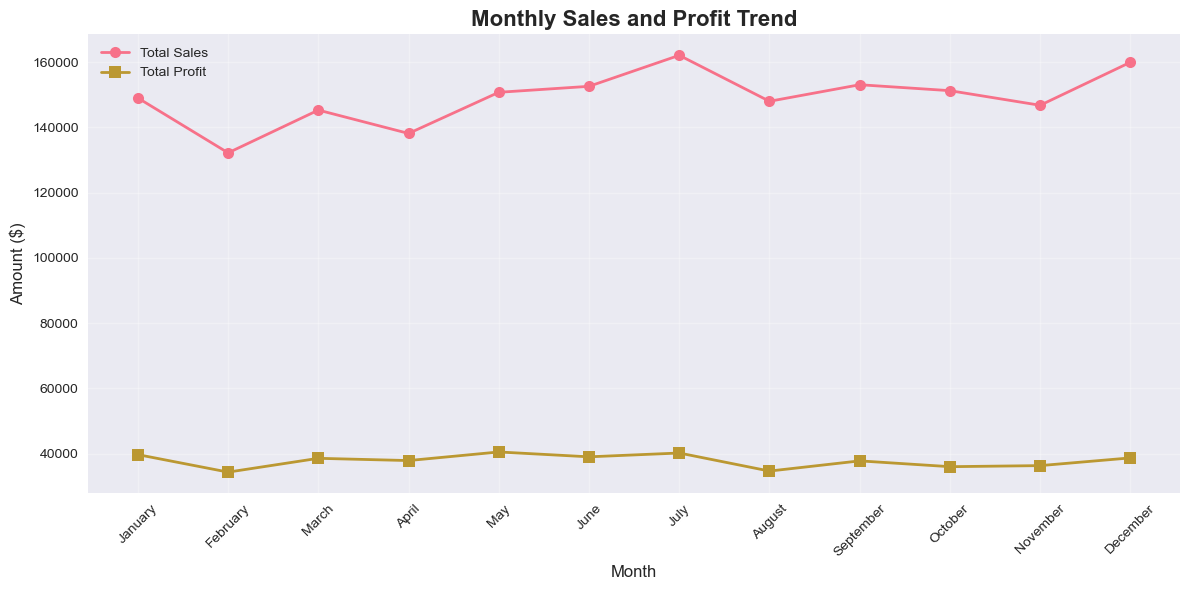

In [76]:
#Visualization 1: Monthly Sales Trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['MonthName'], monthly_sales['Sales'],
marker='o', linewidth=2, markersize=8, label='Total Sales')
plt.plot(monthly_sales['MonthName'], monthly_sales ['Profit'],
marker='s', linewidth=2, markersize=8, label='Total Profit')
plt.title('Monthly Sales and Profit Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
# Explanation: This cell analyzes performance across different pattern sales, and creates a bar chart visualizing total sales by category

In [79]:
# Category Performance Analysis
print("=== CATEGORY PERFORMANCE ANALYSIS ===")
category_performance = df.groupby('Category').agg({
'Sales': 'sum',
'Profit':'sum',
'Quantity':'sum'
}).sort_values('Sales', ascending=False)
print("Category Performance (Sorted by Sales):")
print(category_performance)

=== CATEGORY PERFORMANCE ANALYSIS ===
Category Performance (Sorted by Sales):
                     Sales        Profit     Quantity
Category                                             
Books        370971.872558  92304.452141  3737.000000
Electronics  365070.888965  90439.697795  3595.000000
Clothing     355420.126737  90889.437106  3670.000000
Sports       347665.545975  92065.220851  8394.413386
Home Goods   347493.827088  87447.820056  3777.000000
Null           1106.847949    381.784578    11.000000
NaN?            828.585950     88.591355    12.000000
Nan             823.190573    253.433301     4.000000


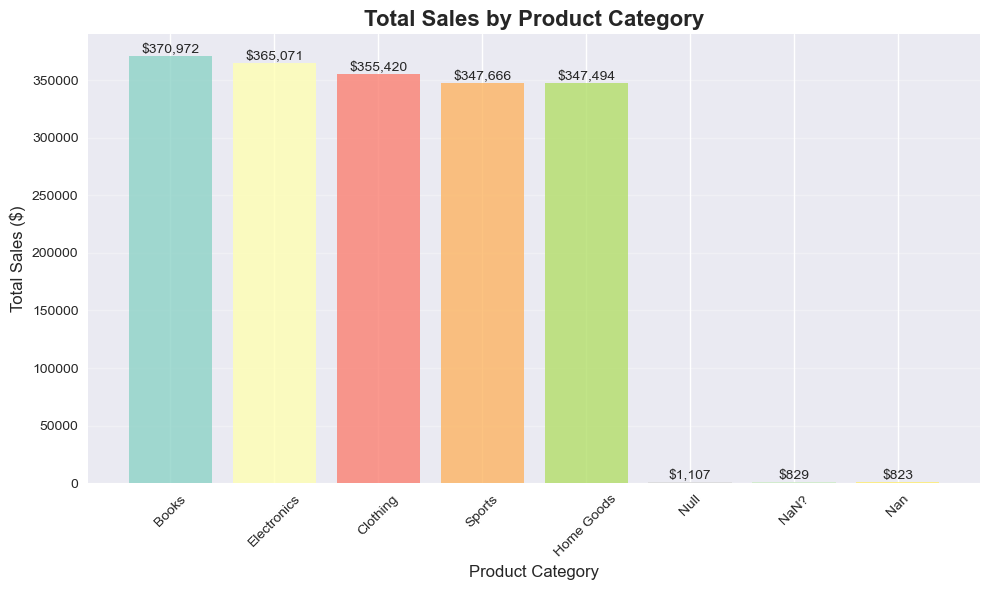

In [58]:
# Visualization 2: Top Categories by Sales
plt.figure(figsize=(10, 6))
colors =plt.cm.Set3(np.linspace(0, 1, len (category_performance)))
bars= plt.bar(category_performance.index, category_performance ['Sales'],            
              color=colors, alpha=0.8)
# Add value Labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,             
            f'${height:,.0f}', ha='center', va='bottom')
plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [59]:
# Explanation: This cell analyzes sales performance across different showing the distribution of sales by region.